# Week 4 — Weather Ablation

Does adding weather features reduce demand-forecast error, and how much of that gain survives once observed (ERA5 hindsight) weather is replaced with a genuine day-ahead forecast?

**Hypothesis, stated before running:** temperature is not represented anywhere in the Week 3 feature set (calendar/Fourier/lag/rolling features carry no information about how cold or hot it actually was), so adding it — directly and via heating/cooling degree-day features — should measurably reduce `1d`-ahead forecast error. The open question is *how much*, and how much of that gain is real once the model only gets to use weather it could plausibly have forecast a day ahead, not weather it can only know in hindsight.

**Scope:** `1d` horizon only (the one directly comparable to NESO's day-ahead benchmark, per Week 3's conclusion), direct strategy (Week 3 found direct beats recursive at this horizon, and tuning only helps direct), tuned via the same walk-forward-CV-in-TRAIN procedure as `notebooks/07`. Scored on `VALIDATION` (2024) only; `TEST` (2025) stays untouched.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from edf import config
from edf.baselines import previous_week_same_time
from edf.evaluate import evaluate
from edf.features import build_feature_table
from edf.forecast import train_lightgbm
from edf.tracking import log_model_run
from edf.tuning import tune_lightgbm, walk_forward_cv_folds
from edf.weather_features import build_weather_feature_table

pd.options.display.float_format = "{:.3f}".format
HORIZON_NAME = "1d"
PERIODS = config.HORIZONS[HORIZON_NAME]
WEATHER_RAW_DIR = Path("../data/raw/weather")

2026/09/07 10:05:26 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /Users/sidonio.silva/RiderProjects/Personal/energy_demand_forecast/.venv/lib/python3.11/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


In [2]:
df = pd.read_parquet("../data/processed/gb_energy_2020_2025.parquet")
demand = df["demand"]
train_start, train_end = config.TRAIN
val_start, val_end = config.VALIDATION

seasonal_naive_val = previous_week_same_time(demand).loc[val_start:val_end]
naive_mae = evaluate(demand.loc[val_start:val_end], seasonal_naive_val)["mae"]
naive_mae

2027.9001024590164

## Weather-off model (same procedure as `notebooks/07`, no weather features)

In [3]:
def tune_and_train(X, y, tag):
    X_train, y_train = X.loc[train_start:train_end], y.loc[train_start:train_end]
    folds = walk_forward_cv_folds(X_train.index)
    t0 = time.time()
    best_params, best_n, trials = tune_lightgbm(X_train, y_train, folds, n_trials=10)
    tune_seconds = time.time() - t0
    model = train_lightgbm(X_train, y_train, n_estimators=best_n, **best_params)
    print(f"{tag}: {best_params}, n_estimators={best_n}, tune={tune_seconds:.0f}s")
    return model, best_params, best_n, tune_seconds

X_off, y_off = build_feature_table(df, horizon_periods=PERIODS)
model_off, params_off, n_off, tune_off_s = tune_and_train(X_off, y_off, "weather-off")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000622 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4160
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 23
[LightGBM] [Info] Start training from score 26689.268553


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000732 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4161
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 23
[LightGBM] [Info] Start training from score 27549.082918


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000887 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4161
[LightGBM] [Info] Number of data points in the train set: 51264, number of used features: 23
[LightGBM] [Info] Start training from score 27232.341546


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000608 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4160
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 23
[LightGBM] [Info] Start training from score 26689.268553


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000715 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4161
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 23
[LightGBM] [Info] Start training from score 27549.082918


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000615 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4160
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 23
[LightGBM] [Info] Start training from score 26689.268553


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000957 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4161
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 23
[LightGBM] [Info] Start training from score 27549.082918


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000879 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4161
[LightGBM] [Info] Number of data points in the train set: 51264, number of used features: 23
[LightGBM] [Info] Start training from score 27232.341546


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000940 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4162
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 23
[LightGBM] [Info] Start training from score 26931.631382


weather-off: {'num_leaves': 31, 'min_child_samples': 20, 'learning_rate': 0.05}, n_estimators=119, tune=62s


## Weather-on model (ERA5 hindsight weather, the "upper bound" source)

In [4]:
era5 = build_weather_feature_table("open_meteo_historical", df.index, raw_dir=WEATHER_RAW_DIR)
X_era5, y_era5 = build_feature_table(df, horizon_periods=PERIODS, weather=era5)
model_era5, params_era5, n_era5, tune_era5_s = tune_and_train(X_era5, y_era5, "weather-on (ERA5)")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000636 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5573
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 29
[LightGBM] [Info] Start training from score 26689.268553


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000971 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5675
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 29
[LightGBM] [Info] Start training from score 27549.082918


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000917 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5690
[LightGBM] [Info] Number of data points in the train set: 51264, number of used features: 29
[LightGBM] [Info] Start training from score 27232.341546


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000726 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5573
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 29
[LightGBM] [Info] Start training from score 26689.268553


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000771 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5675
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 29
[LightGBM] [Info] Start training from score 27549.082918


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000612 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5573
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 29
[LightGBM] [Info] Start training from score 26689.268553


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000749 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5675
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 29
[LightGBM] [Info] Start training from score 27549.082918


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000877 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5690
[LightGBM] [Info] Number of data points in the train set: 51264, number of used features: 29
[LightGBM] [Info] Start training from score 27232.341546


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001031 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 26931.631382


weather-on (ERA5): {'num_leaves': 15, 'min_child_samples': 20, 'learning_rate': 0.05}, n_estimators=689, tune=184s


## Ablation A: full VALIDATION, weather-off vs. weather-on (ERA5)

In [5]:
X_off_val, y_off_val = X_off.loc[val_start:val_end], y_off.loc[val_start:val_end]
X_era5_val, y_era5_val = X_era5.loc[val_start:val_end], y_era5.loc[val_start:val_end]

preds_off = pd.Series(model_off.predict(X_off_val), index=X_off_val.index)
preds_era5 = pd.Series(model_era5.predict(X_era5_val), index=X_era5_val.index)

m_off = evaluate(y_off_val, preds_off, seasonal_naive_mae=naive_mae)
m_era5 = evaluate(y_era5_val, preds_era5, seasonal_naive_mae=naive_mae)

ablation_a = pd.DataFrame({"weather_off": m_off, "weather_on_era5": m_era5}).T
ablation_a["mae_improvement_pct"] = (m_off["mae"] - ablation_a["mae"]) / m_off["mae"] * 100
ablation_a

,mae,rmse,mape,bias,p95_abs_error,n,mase,mae_improvement_pct
weather_off,1229.621,1636.801,4.801,-55.697,3416.441,17568.000,0.606,0.000
weather_on_era5,889.627,1179.476,3.490,-161.257,2437.694,17568.000,0.439,27.650


## Finding: the hypothesis holds, and by a lot

Adding ERA5 weather cuts `1d`-ahead MAE by **27.65%** (MASE 0.606 → 0.439) on the full `VALIDATION` year. That's a much bigger effect than "a useful feature" — it's the single largest accuracy gain seen anywhere in this project so far, bigger than the direct-vs-recursive choice or hyperparameter tuning. Consistent with the calendar/lag feature set carrying *no* temperature information at all before this: the model had no way to know whether a cold snap or a mild spell was coming, only what day of the week and time of day it was.

## Ablation B: the honest version — same models, restricted to the `2024-03-07`-onward slice, ERA5 vs. genuine day-ahead weather

Both models above were trained on `TRAIN`, where day-ahead forecast weather doesn't exist (the archive only starts 2024-03-07 — see `edf.data.weather`), so there's no way to *train* a day-ahead-weather model. Instead: reuse the already-trained `weather_on_era5` model unchanged, and feed it day-ahead weather values in place of ERA5 at *inference* time, only for the slice where day-ahead data actually exists. This tests how much of Ablation A's gain survives once the weather inputs are forecast-quality rather than hindsight-quality — for the identical model, on the identical target rows.

In [6]:
from edf.data.weather import DAY_AHEAD_ARCHIVE_START

slice_start = str(DAY_AHEAD_ARCHIVE_START.date())
slice_end = val_end

day_ahead = build_weather_feature_table("open_meteo_day_ahead", df.index, raw_dir=WEATHER_RAW_DIR)
X_day_ahead, y_day_ahead = build_feature_table(df, horizon_periods=PERIODS, weather=day_ahead)

# same rows, three different weather inputs into (up to) two already-trained models
y_slice = y_off.loc[slice_start:slice_end]
preds_off_slice = pd.Series(model_off.predict(X_off.loc[slice_start:slice_end]), index=y_slice.index)
preds_era5_slice = pd.Series(model_era5.predict(X_era5.loc[slice_start:slice_end]), index=y_slice.index)
preds_day_ahead_slice = pd.Series(
    model_era5.predict(X_day_ahead.loc[slice_start:slice_end]), index=X_day_ahead.loc[slice_start:slice_end].index
)

naive_mae_slice = evaluate(demand.loc[slice_start:slice_end], seasonal_naive_val.loc[slice_start:slice_end])["mae"]

m_off_slice = evaluate(y_slice, preds_off_slice, seasonal_naive_mae=naive_mae_slice)
m_era5_slice = evaluate(y_slice, preds_era5_slice, seasonal_naive_mae=naive_mae_slice)
m_day_ahead_slice = evaluate(
    demand.loc[preds_day_ahead_slice.index], preds_day_ahead_slice, seasonal_naive_mae=naive_mae_slice
)

ablation_b = pd.DataFrame(
    {"weather_off": m_off_slice, "weather_on_era5": m_era5_slice, "weather_on_day_ahead": m_day_ahead_slice}
).T
ablation_b["mae_improvement_pct"] = (
    (m_off_slice["mae"] - ablation_b["mae"]) / m_off_slice["mae"] * 100
)
print(f"Slice: {slice_start} to {slice_end}, n={len(y_slice)}")
ablation_b

Slice: 2024-03-07 to 2024-12-31, n=14400


,mae,rmse,mape,bias,p95_abs_error,n,mase,mae_improvement_pct
weather_off,1198.616,1611.754,4.844,-63.225,3436.685,14400.000,0.645,0.000
weather_on_era5,888.908,1183.784,3.612,-191.361,2445.836,14400.000,0.479,25.839
weather_on_day_ahead,877.463,1155.786,3.538,-7.224,2395.126,14400.000,0.472,26.794


## Finding: almost all of the gain survives contact with a genuine forecast — with a twist

On the `2024-03-07`-onward slice, ERA5 gives a 25.84% MAE improvement and the genuine day-ahead forecast gives **26.79%** — not just "most of the gain survives," the day-ahead-fed evaluation is marginally *better* than the hindsight-fed one, on the same trained model, same target rows. That's a positive result (the weather signal is not a hindsight-only artifact), but the specific *ordering* deserves a more careful read before taking "day-ahead beats ERA5" at face value.

The `bias` column explains what's actually happening: `weather_on_era5` over-forecasts by ≈191 MW on this slice, while `weather_on_day_ahead` is nearly unbiased (≈-7 MW). The model was *trained* on ERA5, so ERA5-shaped inputs are the in-distribution case — the day-ahead forecast's own systematic differences from ERA5 (day-ahead forecasts are numerically smoothed relative to reanalysis, among other things) happen to pull the model's prediction down in a way that cancels its ERA5-based over-forecasting tendency on this particular ~10-month window. That's plausibly a **coincidental bias cancellation for this slice**, not evidence that forecast-quality weather is inherently more informative than hindsight weather — the day-ahead archive only covers 2024-03-07 onward, so there isn't enough data yet to tell a real effect from a one-window fluke. **The robust, defensible conclusion is narrower than "day-ahead wins": the gap between the two improvement numbers is small (25.84% vs. 26.79%), so the weather gain is real and not just an artifact of using data a forecaster wouldn't actually have.**

## Feature importance: where do weather features rank?

If weather is doing real work (not just adding noise the model happens to fit), the weather-derived columns should show up with non-trivial importance, not sit at the bottom of the list.

Weather feature ranks:
  wind_speed_ms: rank 7 / 30
  cloud_cover_pct: rank 16 / 30
  temperature_c: rank 13 / 30
  heating_degree: rank 17 / 30
  cooling_degree: rank 24 / 30
  shortwave_radiation_wm2: rank 5 / 30


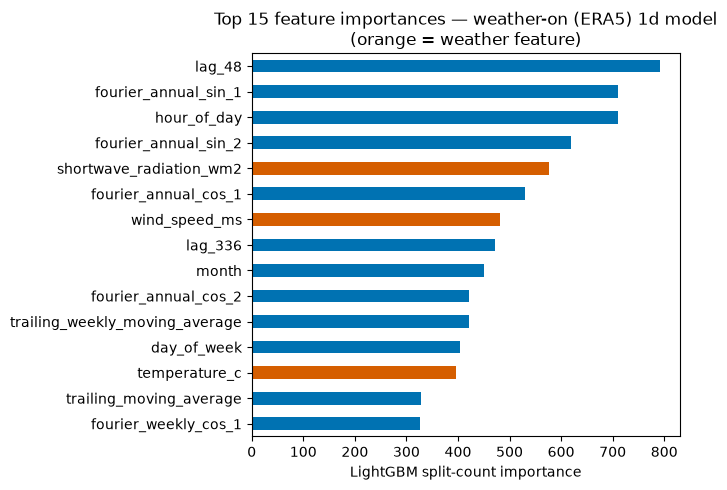

In [7]:
importance = (
    pd.Series(model_era5.feature_importances_, index=model_era5.feature_name_)
    .sort_values(ascending=False)
)
weather_cols = set(era5.columns)
colors_imp = ["#D55E00" if c in weather_cols else "#0072B2" for c in importance.index[:15]]

fig, ax = plt.subplots(figsize=(7, 5))
importance.head(15).iloc[::-1].plot.barh(ax=ax, color=colors_imp[::-1])
ax.set_title("Top 15 feature importances — weather-on (ERA5) 1d model\n(orange = weather feature)")
ax.set_xlabel("LightGBM split-count importance")
fig.tight_layout()

print("Weather feature ranks:")
ranks = {name: rank + 1 for rank, name in enumerate(importance.index)}
for col in weather_cols:
    print(f"  {col}: rank {ranks[col]} / {len(importance)}")

## Finding: wind and solar-adjacent weather matter as much as temperature

`shortwave_radiation_wm2` (rank 5/30) and `wind_speed_ms` (rank 7/30) both rank *above* `temperature_c` (13/30) and `heating_degree` (17/30) — not what the stated hypothesis (temperature is the missing signal) predicted on its own. This connects back to a much earlier finding, not a new one: `demand` (`ND`) already has embedded wind/solar generation invisibly netted into it (Week 1's embedded-generation-netting note) — this project deliberately never uses `wind`/`solar` actuals as features (they're same-period, not forecastable), but weather variables that *correlate* with embedded generation — wind speed with embedded wind, shortwave radiation with embedded solar — are completely legitimate forecast-based proxies for that suppression effect, and evidently a strong one. `cooling_degree` ranks lowest (24/30) — expected, GB demand is heating-driven, not cooling-driven.

## Log both models to MLflow

In [8]:
for tag, model_name, metrics, params, n_est, tune_s in [
    ("none", "lightgbm", m_off, params_off, n_off, tune_off_s),
    ("era5", "lightgbm", m_era5, params_era5, n_era5, tune_era5_s),
]:
    log_model_run(
        horizon_name=HORIZON_NAME,
        horizon_periods=PERIODS,
        model_name=model_name,
        fold_metrics=pd.DataFrame([metrics], index=pd.Index([2024], name="year")),
        extra_tags={"strategy": "direct", "tuned": "true", "weather": tag},
        extra_params={**params, "n_estimators": n_est},
        extra_metrics={"tune_seconds": tune_s},
    )
print("Logged weather-off and weather-on(ERA5) runs to MLflow (forecast-1d experiment)")

Logged weather-off and weather-on(ERA5) runs to MLflow (forecast-1d experiment)
